# Data Preparation -base table

## Data Source

The dataset consists of two CSV files exported from Salesforce.  
They were generated as a result of an email campaign with A/B testing (sent vs. not sent).  
Each file contains information about customers and their subscription behavior.

Due to Salesforce limitations, campaign data does not include the actual cancellation request date.
An additional report was used to extract **"Kündigung erfasst am"**, which reflects the true timing of churn.

## Imports
This section imports the necessary Python libraries for data processing and analysis.

In [136]:
import pandas as pd
from pathlib import Path
import re
import unicodedata

## Data Loading
In this section, two CSV files from the A/B test campaign are loaded and combined into a single dataset.
It was also loaded the CSV file with timing of churn.
`cancel_date` is used for analysis instead of `end_date` to avoid time lag bias (~1 month delay between request and contract end).

In [ ]:
base_path = Path("../Data/raw")

read_kwargs = {
    "sep": ";",
    "dtype": {"SAP GP Nummer": "string"}
}

# load campaign datasets (treatment / control)
df1 = pd.read_csv(base_path / "Kampagnenmitglieder_nein_raw.csv", **read_kwargs)
df2 = pd.read_csv(base_path / "Kampagnenmitglieder_ja_raw.csv", **read_kwargs)

# load cancellation request data ("Kündigung erfasst am")
df_kuend = pd.read_csv(base_path / "Kuendigung erfasst am-2026-04-22-15-57-421.csv", **read_kwargs)

# keep relevant columns from campaign data
relevant_cols = [
    "SAP GP Nummer",
    "letzter Abo - Auftrag: Auftrag von",
    "letzter Abo - Auftrag: Auftrag bis",
    "letzter Abo - Auftrag: Kündigungsgrund Code"
]

df1_clean = df1[relevant_cols].copy()
df2_clean = df2[relevant_cols].copy()

# add treatment indicator
df1_clean["treatment"] = 0
df2_clean["treatment"] = 1

# combine groups
df = pd.concat([df1_clean, df2_clean], ignore_index=True)

# rename columns
df = df.rename(columns={
    "SAP GP Nummer": "customer_id",
    "letzter Abo - Auftrag: Auftrag von": "start_date",
    "letzter Abo - Auftrag: Auftrag bis": "end_date",
    "letzter Abo - Auftrag: Kündigungsgrund Code": "cancel_reason"
})

# keep relevant columns from cancellation dataset
df_kuend_clean = df_kuend[[
    "SAP GP Nummer",
    "letzter Abo - Auftrag: Kündigung erfasst am",
    "zuletzt aktiv Portal"
]].copy()

df_kuend_clean = df_kuend_clean.rename(columns={
    "SAP GP Nummer": "customer_id",
    "letzter Abo - Auftrag: Kündigung erfasst am": "cancel_date",
})

for col in df.columns:
    print(col)


for col in df_kuend_clean.columns:
    print(col)


customer_id
start_date
end_date
cancel_reason
treatment
customer_id
cancel_date
zuletzt aktiv Portal


## data type harmonization

In [138]:
# unify key type
df["customer_id"] = df["customer_id"].astype(str).str.strip()
df_kuend_clean["customer_id"] = df_kuend_clean["customer_id"].astype(str).str.strip()

# convert dates
df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce", dayfirst=True)
df["end_date"] = pd.to_datetime(df["end_date"], errors="coerce", dayfirst=True)
df_kuend_clean["cancel_date"] = pd.to_datetime(
    df_kuend_clean["cancel_date"], errors="coerce", dayfirst=True
)

# inspect column types
print(df.dtypes)
print("\n--- df_kuend_clean ---\n")
print(df_kuend_clean.dtypes)

customer_id                 str
start_date       datetime64[us]
end_date         datetime64[us]
cancel_reason               str
treatment                 int64
dtype: object

--- df_kuend_clean ---

customer_id                        str
cancel_date             datetime64[us]
zuletzt aktiv Portal               str
dtype: object


## deduplication 

In [139]:
# total number of rows
len(df)

# number of duplicated customer_ids
df["customer_id"].duplicated().sum()

# difference between total rows and unique customers (should be 0 if no duplicates)
len(df) - df["customer_id"].nunique()

# before deduplication
print("rows before:", len(df_kuend_clean))
print("duplicate customer_ids:", df_kuend_clean["customer_id"].duplicated().sum())

# deduplication
df_kuend_clean = (
    df_kuend_clean
    .sort_values("cancel_date")
    .drop_duplicates("customer_id", keep="first")
)

# after deduplication
print("rows after:", len(df_kuend_clean))
print("duplicate customer_ids after:", df_kuend_clean["customer_id"].duplicated().sum())

# check duplicate customers in campaign data
customer_counts = df["customer_id"].value_counts()

print("customers with more than one row:", (customer_counts > 1).sum())
print("duplicate rows:", df["customer_id"].duplicated().sum())
customer_counts[customer_counts > 1].head(20)

rows before: 2295
duplicate customer_ids: 0
rows after: 2295
duplicate customer_ids after: 0
customers with more than one row: 0
duplicate rows: 0


Series([], Name: count, dtype: int64)

## dataset construction

In [140]:
# merge
df = df.merge(df_kuend_clean, on="customer_id", how="left")

# check number of rows
print("rows after merge:", len(df))
df.head()


rows after merge: 28566


,customer_id,start_date,end_date,cancel_reason,treatment,cancel_date,zuletzt aktiv Portal
0,0018640485,2022-12-05,NaT,NaN,0,NaT,NaN
1,0018703242,2026-04-14,2028-04-13,BEF,0,NaT,NaN
2,0019173245,2026-04-01,NaT,NaN,0,NaT,NaN
3,0019173659,2021-01-01,NaT,NaN,0,NaT,NaN
4,0019173423,2025-10-01,NaT,NaN,0,NaT,NaN


## date issues

In [141]:
# check date issues

today = pd.Timestamp.today().normalize()

# future dates
future_start = df["start_date"] > today
future_cancel = df["cancel_date"] > today

print("start_date future:", future_start.sum())
print("cancel_date future:", future_cancel.sum())

# wrong order
wrong_order = (
    df["start_date"].notna() &
    df["end_date"].notna() &
    (df["end_date"] < df["start_date"])
)

print("end_date < start_date:", wrong_order.sum())

# show problematic rows
problem_rows = df[
    future_start | future_cancel | wrong_order
][["customer_id", "start_date", "end_date", "cancel_date"]]

problem_rows.sort_values("customer_id").head(20)

# --- remove invalid rows ---

df_clean = df[
    (~future_start) & 
    (~future_cancel) & 
    (~wrong_order)
].copy()

start_date future: 1
cancel_date future: 0
end_date < start_date: 0


## sample definition
### Exclude cancellations with technical or exogenous reasons:
- AKP – downgrade due to age/health/care-related reasons 
- GPW – customer ID change (technical)
- KIN – internal contract transitions
- KOR – correction (technical adjustment)
- KZA – cancellation due to non-payment
- KÜP – cancellation withdrawal via portal
- KÜR – cancellation with retention attempt (win-back)
- LEG – life circumstances changed
- TOD – deceased
- UMZ – relocation (move)

In [142]:
# show all unique cancellation reasons
df["cancel_reason"].dropna().sort_values().unique()

<StringArray>
['AKP', 'AME', 'AZE', 'BEF', 'BES', 'BON', 'DPB', 'DPZ', 'FIN', 'GPW', 'INH',
  'KA',  'KI', 'KIN', 'KOR', 'KZA', 'KZE', 'KÜP', 'KÜR', 'LEG', 'NZU', 'PRE',
 'PSL', 'SER', 'TEC', 'TOD', 'TRE', 'UMZ', 'WID']
Length: 29, dtype: str

In [143]:
# examples KIN
df[df["cancel_reason"] == "KIN"][
    ["customer_id", "start_date", "end_date", "cancel_reason"]
].head(5)

,customer_id,start_date,end_date,cancel_reason
1798,0019300717,2026-04-02,2026-04-30,KIN
2945,0019264071,2024-05-02,2026-05-01,KIN
4047,0019335639,2024-06-27,2026-06-26,KIN
4471,0019541568,2026-01-01,2026-03-31,KIN
5041,0019605306,2026-01-01,2026-04-07,KIN


In [144]:
# reasons to exclude
exclude_reasons = ["GPW", "KIN", "KOR", "KZA", "TOD", "UMZ"]

counts = (
    df["cancel_reason"]
    .value_counts(dropna=False)
    .loc[lambda x: x.index.isin(exclude_reasons)]
)

print("=== EXCLUSION CRITERIA CHECK ===")
print(counts)

# filtering
df = df[~df["cancel_reason"].isin(exclude_reasons)].copy()

# report AFTER
print("\n=== AFTER FILTERING ===")
print("rows remaining:", len(df))

=== EXCLUSION CRITERIA CHECK ===
cancel_reason
KIN    32
TOD    30
UMZ    24
KZA    21
GPW     1
KOR     1
Name: count, dtype: int64

=== AFTER FILTERING ===
rows remaining: 28457


In [145]:
print(df["cancel_date"].notna().sum())

344


# Data Preparation - feature table

## Data Source 
The feature table is provided as a CSV file compiled from BigQuery, where data is ingested via event streams from digital platforms, 
as well as integrated sources such as Salesforce and SAP.

In [146]:
df_check = df[[
    "customer_id",
    "start_date",
    "end_date",
    "cancel_date",
    "cancel_reason",
    "last_activity"
]].copy()

# только где есть обе даты
df_both = df_check.dropna(subset=["end_date", "cancel_date", "last_activity"])

len(df)
df["last_activity"].notna().sum()
len(df_both)

KeyError: "['last_activity'] not in index"

In [ ]:
# define observation window for post-campaign churn
start = pd.Timestamp("2026-03-19")
end = pd.Timestamp("2026-04-19")

# create churn variable: 1 if subscription ended within the observation window
df["churn"] = (
    df["end_date"].notna() &
    (df["end_date"] >= start) &
    (df["end_date"] <= end)
).astype(int)

# overall churn rate (%)
overall_churn = df["churn"].mean() * 100

# overall churn by treatment group (%)
churn_by_group = df.groupby("treatment")["churn"].mean() * 100
churn_by_group.index = ["Not sent", "Sent"]

# KA churn based on the same base: all customers in each group
ka_churn_by_group = df.groupby("treatment").apply(
    lambda x: ((x["churn"] == 1) & (x["cancel_reason"] == "KA")).mean() * 100
)
ka_churn_by_group.index = ["Not sent", "Sent"]

# share of KA among all churned customers (%)
ka_share_among_churned = (
    (df.loc[df["churn"] == 1, "cancel_reason"] == "KA").mean() * 100
)

# print results
print(f"Overall churn: {overall_churn:.4f}%\n")

print("Overall churn by treatment group (%):")
print(churn_by_group.round(4))

print("\nKA churn by treatment group (% of all customers):")
print(ka_churn_by_group.round(4))

print(f"\nShare of KA among all churned customers: {ka_share_among_churned:.4f}%")

Overall churn: 0.7098%

Overall churn by treatment group (%):
Not sent    0.9690
Sent        0.6524
Name: churn, dtype: float64

KA churn by treatment group (% of all customers):
Not sent    0.1357
Sent        0.2189
dtype: float64

Share of KA among all churned customers: 28.7129%


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Große der Gruppe
n_control = (df["treatment"] == 0).sum()
n_treat = (df["treatment"] == 1).sum()

# Anzahl churn
churn_control = df.loc[df["treatment"] == 0, "churn"].sum()
churn_treat = df.loc[df["treatment"] == 1, "churn"].sum()

# delta
delta = (churn_treat / n_treat) - (churn_control / n_control)

# z-test
stat, pval = proportions_ztest(
    [churn_treat, churn_control],
    [n_treat, n_control]
)

print(f"Delta Kündigungsrate: {delta*100:.4f} pp")
print(f"Z-stat: {stat:.4f}")
print(f"P-value: {pval:.4f}")

Delta Kündigungsrate: -0.3165 pp
Z-stat: -2.4507
P-value: 0.0143


In [ ]:
# --- Activity segmentation (correct column name) ---

# parse
df["last_activity"] = pd.to_datetime(
    df["last_activity"],
    errors="coerce",
    dayfirst=True
)

# days since last activity
campaign_date = pd.Timestamp("2026-03-19")

df["days_since_activity"] = (
    campaign_date - df["last_activity"]
).dt.days

# фильтр: не заходил больше недели
df_pre = df[df["days_since_activity"] > 0].copy()

df_pre["activity_group"] = pd.cut(
    df_pre["days_since_activity"],
    bins=[0, 7, 30, 10000],
    labels=["active", "less_active", "inactive"]
)

df_pre.groupby("activity_group")["churn"].mean() * 100
df["churn"].value_counts()


KeyError: 'last_activity'

In [ ]:
# filter only customers who churned in the campaign window
df_window = df[
    (df["churn"] == 1)
].copy()

# count per cancel_reason (only in this month)
counts = df_window["cancel_reason"].value_counts()

# one example customer per reason
examples = (
    df_window[["cancel_reason", "customer_id"]]
    .dropna(subset=["cancel_reason"])
    .drop_duplicates(subset=["cancel_reason"])
    .set_index("cancel_reason")
)

# combine
df_reason_map = (
    counts.to_frame("count")
    .join(examples)
    .reset_index()
    .rename(columns={"index": "cancel_reason"})
)
df_window.groupby(["treatment", "cancel_reason"]).size().reset_index(name="count")

df_reason_map


KeyError: 'churn'

In [ ]:
# define observation window
start = pd.Timestamp("2026-03-19")
end = pd.Timestamp("2026-04-18")

# filter only churned customers in this window
df_window = df[
    (df["cancel_date"].notna()) &
    (df["cancel_date"] >= start) &
    (df["cancel_date"] <= end)
].copy()

# group by treatment and cancel_reason (counts)
result = (
    df_window
    .groupby(["treatment", "cancel_reason"])
    .size()
    .reset_index(name="count")
)

pivot_pct = (
    df_window
    .groupby(["treatment", "cancel_reason"])
    .size()
    .groupby(level=0)
    .apply(lambda x: x / x.sum() * 100)
    .unstack(fill_value=0)
    .T
)

pivot_pct.rename(columns={0: "Not sent", 1: "Sent"}).round(2)

treatment,Not sent,Sent
treatment,Not sent,Sent
cancel_reason,,
AKP,6.15,2.07
AME,0.00,4.96
AZE,1.54,0.00
BEF,4.62,1.24
BON,1.54,0.41
DPZ,0.00,0.41
FIN,3.08,2.07
INH,4.62,3.31


In [ ]:
churn_end = (
    df["end_date"].notna() &
    (df["end_date"] >= start) &
    (df["end_date"] <= end)
).astype(int)

churn_cancel = (
    df["cancel_date"].notna() &
    (df["cancel_date"] >= start) &
    (df["cancel_date"] <= end)
).astype(int)

print((churn_end != churn_cancel).sum())
df["lag_days"] = (df["end_date"] - df["cancel_date"]).dt.days
df["lag_days"].describe()

521


count    411.000000
mean      87.518248
std      130.139031
min       -1.000000
25%       23.000000
50%       29.000000
75%       85.000000
max      680.000000
Name: lag_days, dtype: float64

lag_days
-1.0      5
 0.0     22
 1.0      3
 2.0      1
 5.0      1
 6.0      9
 9.0      4
 10.0     3
 11.0     1
 12.0     1
 13.0     3
 14.0     5
 15.0     5
 16.0     7
 17.0     9
 20.0    10
 21.0     7
 22.0     3
 23.0     6
 24.0     6
Name: count, dtype: int64

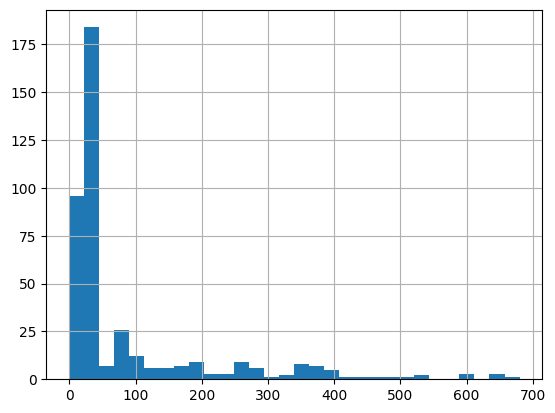

In [ ]:
df["lag_days"] = (df["end_date"] - df["cancel_date"]).dt.days
df["lag_days"].describe()
df["lag_days"].hist(bins=30)
df["lag_days"].value_counts().sort_index().head(20)

In [ ]:
print(df.columns.tolist())
print(df_kuend_clean.columns.tolist())

['customer_id', 'start_date', 'end_date', 'cancel_reason', 'treatment', 'cancel_date', 'last_activity', 'churn', 'tenure_days', 'tenure_group', 'lag_days']
['customer_id', 'cancel_date', 'last_activity']
